# Phase 3 — Neighborhood Clustering (Unsupervised)

Groups zip codes into four growth-stage clusters using K-Means on price and ZHVI-derived features.

**Outputs**
- `data/processed/neighborhood_features.csv`
- `data/processed/cluster_labels.csv`
- `outputs/figures/03_elbow_silhouette.png`
- `outputs/figures/03_clusters.png`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

from src.utils import (
    MERGED_DATA, NEIGHBORHOOD_FEATS, CLUSTER_LABELS, FIGURES_DIR, ensure_dirs
)
from src.clustering import (
    build_neighborhood_features, find_optimal_k, fit_clusters, plot_clusters, CLUSTER_FEATURES
)

ensure_dirs()

## 1. Load Merged Data

In [2]:
df = pd.read_parquet(MERGED_DATA)
print(f'Rows: {len(df):,}  |  Zip codes: {df["zip_code"].nunique():,}')
df.head()

Rows: 856,386  |  Zip codes: 24,790


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,price_per_sqft,price_per_acre,bed_bath_ratio,total_rooms,zhvi_current,zhvi_1yr_ago,growth_1yr,growth_5yr
0,92147.0,for_sale,95000.0,5.0,2.0,0.16,151105.0,Quebradillas,Puerto Rico,95000,1757.0,NaN,54.069435,593750.000000,2.5,7.0,NaN,NaN,NaN,NaN
1,10368.0,for_sale,175000.0,3.0,1.0,60.00,553526.0,Berlin,New York,12022,1176.0,NaN,148.809525,2916.666748,3.0,4.0,245358.593423,243545.945065,0.007443,0.258139
2,22006.0,for_sale,425000.0,3.0,2.0,2.02,263302.0,Claverack,New York,12521,1600.0,2021-11-24,265.625000,210396.046875,1.5,5.0,477275.645292,446806.854928,0.068192,0.489499
3,48310.0,for_sale,225000.0,4.0,2.0,0.24,871278.0,Copake,New York,12521,1239.0,2018-02-01,181.598068,937500.000000,2.0,6.0,477275.645292,446806.854928,0.068192,0.489499
4,7797.0,for_sale,419000.0,3.0,3.0,1.90,286373.0,Copake,New York,12516,1800.0,NaN,232.777771,220526.312500,1.0,6.0,460065.545843,431260.572796,0.066793,0.490520


## 2. Build Neighborhood Features

Aggregates listings to zip-code level: median price, median price/sqft, ZHVI, and growth rates. Adds `log_median_price` and `price_to_zhvi` ratio.

In [3]:
hood = build_neighborhood_features(df)
print(f'Neighborhoods (zip codes with ZHVI): {len(hood):,}')
hood.describe().round(2)

Neighborhoods (zip codes with ZHVI): 21,529


,median_price,median_price_sqft,listing_count,median_house_size,zhvi_current,growth_1yr,growth_5yr,log_median_price,price_to_zhvi
count,21529.00,21529.00,21529.00,21529.00,21529.00,21529.00,21529.00,21529.00,21529.00
mean,397381.22,207.50,39.40,1869.51,362407.09,0.02,0.29,12.59,1.08
std,428908.28,189.14,57.99,638.10,327684.76,0.05,0.16,0.74,0.44
min,12334.00,7.62,1.00,150.00,28552.41,-0.42,-0.60,9.42,0.07
25%,179950.00,111.87,5.00,1484.00,194520.70,-0.01,0.21,12.10,0.85
50%,290000.00,159.53,17.00,1758.00,280200.69,0.02,0.31,12.58,1.00
75%,454900.00,232.95,53.00,2108.00,413935.70,0.04,0.39,13.03,1.19
max,8888880.00,4977.61,1138.00,17024.00,8078218.89,0.35,1.12,16.00,3.36


In [4]:
hood.to_csv(NEIGHBORHOOD_FEATS, index=False)
print(f'Saved → {NEIGHBORHOOD_FEATS}')

Saved → /Users/zacharypeng/projects/csen140proj/notebooks/../data/processed/neighborhood_features.csv


## 3. Find Optimal K

Sweeps k from 2–8 and plots the elbow curve and silhouette score.

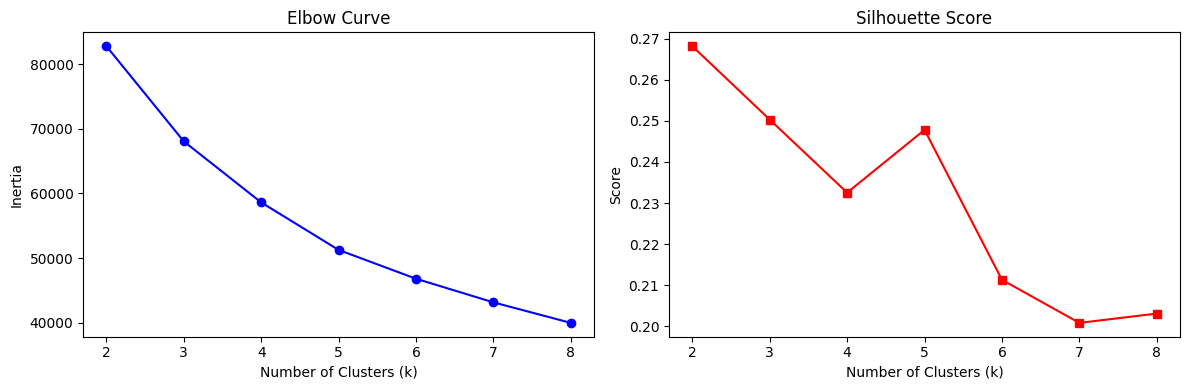


Best k by silhouette: 2  (score=0.268)
Silhouette-optimal k: 2


In [5]:
best_k, X_scaled = find_optimal_k(
    hood,
    save_path=FIGURES_DIR / '03_elbow_silhouette.png'
)
print(f'Silhouette-optimal k: {best_k}')

## 4. Fit Clusters

We use **k = 4** to get four interpretable growth stages (Declining / Stable / Emerging / Gentrifying). Labels are assigned by a quadrant rule on price level × 5-year growth.

In [6]:
K = 4
hood, km = fit_clusters(hood, X_scaled, k=K)


Final Silhouette Score (k=4): 0.227

               log_median_price  median_price_sqft  price_to_zhvi  growth_1yr  \
cluster_label                                                                   
Declining                12.103         132.492004          1.201      -0.046   
Emerging                 12.999         236.528000          1.152       0.008   
Gentrifying              12.087         119.811996          0.837       0.048   
Stable                   14.104         725.109985          1.745       0.009   

               growth_5yr  median_price  growth_5yr  
cluster_label                                        
Declining           0.066  2.133403e+05       0.066  
Emerging            0.303  4.755166e+05       0.303  
Gentrifying         0.374  1.944797e+05       0.374  
Stable              0.269  1.545064e+06       0.269  

Zip codes per cluster:
cluster_label
Emerging       9012
Gentrifying    8045
Declining      3157
Stable         1315


In [7]:
print('Cluster summary (mean feature values):')
hood.groupby('cluster_label')[CLUSTER_FEATURES].mean().round(3)

Cluster summary (mean feature values):


,log_median_price,median_price_sqft,price_to_zhvi,growth_1yr,growth_5yr
cluster_label,,,,,
Declining,12.103,132.492004,1.201,-0.046,0.066
Emerging,12.999,236.528000,1.152,0.008,0.303
Gentrifying,12.087,119.811996,0.837,0.048,0.374
Stable,14.104,725.109985,1.745,0.009,0.269


In [8]:
hood[['zip_code', 'cluster', 'cluster_label']].to_csv(CLUSTER_LABELS, index=False)
print(f'Saved → {CLUSTER_LABELS}')

Saved → /Users/zacharypeng/projects/csen140proj/notebooks/../data/processed/cluster_labels.csv


## 5. Visualize Clusters

Scatter: 1-year growth vs median price/sqft, coloured by cluster label.

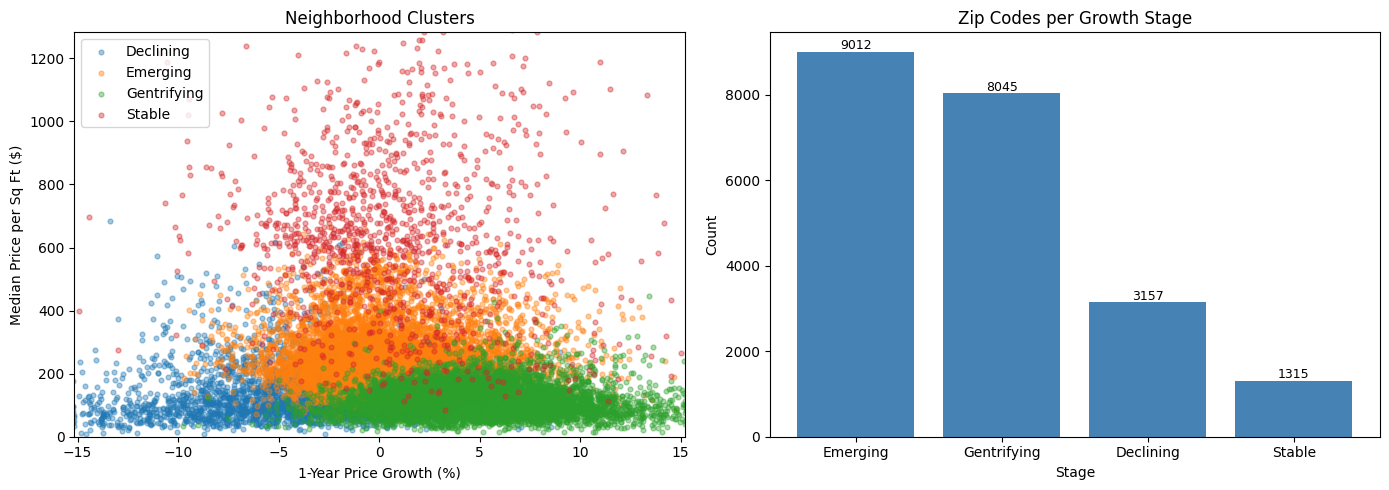

Saved → outputs/figures/03_clusters.png


In [9]:
plot_clusters(hood, save_path=FIGURES_DIR / '03_clusters.png')
print('Saved → outputs/figures/03_clusters.png')